# Esame Finale — Machine Learning Supervisionato

---

## Brief Aziendale

Sei un Data Scientist del team di **BIP AI LAB**. La nostra azienda collabora costantemente con diversi clienti operanti in svariati settori, aiutandoli a estrarre valore dai loro dati storici per supportare le decisioni strategiche del management.

A seconda del cliente a cui verrai assegnato, avrai a disposizione uno specifico dataset su cui sviluppare la tua soluzione predittiva. Tieni a mente che ogni dataset pone sfide differenti e richiede considerazioni e approcci mirati, soprattutto nelle fasi di analisi e preparazione dei dati.

## Istruzioni per lo Svolgimento

Il tuo compito principale sarà quello di scegliere il modello di machine learning supervisionato più appropriato per il tuo caso di studio, selezionandolo tra quelli affrontati durante il corso: la **Linear Regression** o la **Logistic Regression**.

Dovrai gestire l'intera pipeline per estrarre valore dai dati che ti sono stati assegnati, addestrare il modello secondo le tecniche studiate e valutarne l'output nel contesto specifico del problema. Poni particolare enfasi sulla comprensione del contesto dei dati: sarà fondamentale per compiere delle scelte analitiche mirate, che dovrai poi giustificare durante la presentazione finale.

Buon lavoro.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer

plt.rcParams["figure.figsize"] = (7, 4.5)
RANDOM_STATE = 42

## 1. Caricamento dati

In [3]:
df = pd.read_csv("boston_housing.csv")
print("Numero di immobili:", len(df))
df.head()

Numero di immobili: 506


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [4]:
df.describe().round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.00,486.00,486.00,486.00,506.00,506.00,486.00,506.00,506.00,506.00,506.00,506.00,486.00,506.00
mean,3.61,11.21,11.08,0.07,0.55,6.28,68.52,3.80,9.55,408.24,18.46,356.67,12.72,22.53
std,8.72,23.39,6.84,0.26,0.12,0.70,28.00,2.11,8.71,168.54,2.16,91.29,7.16,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.18,2.10,4.00,279.00,17.40,375.38,7.12,17.02
50%,0.25,0.00,9.69,0.00,0.54,6.21,76.80,3.21,5.00,330.00,19.05,391.44,11.43,21.20
75%,3.56,12.50,18.10,0.00,0.62,6.62,93.98,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


## 2. Valori mancanti

Alcune feature numeriche e la variabile binaria CHAS presentano il 4% circa di valori mancanti: li imputiamo invece di eliminare le righe.

In [5]:
df.isna().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [6]:
df_clean = df.copy()
num_cols = ["CRIM", "ZN", "INDUS", "AGE", "LSTAT"]
cat_cols = ["CHAS"]

# media per le numeriche, moda per CHAS (variabile binaria)
df_clean[num_cols] = SimpleImputer(strategy="mean").fit_transform(df_clean[num_cols])
df_clean[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(df_clean[cat_cols])

df_clean.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

## 3. Esplorazione di target e feature

Distribuzione di MEDV, correlazioni e relazione con le feature più rilevanti.

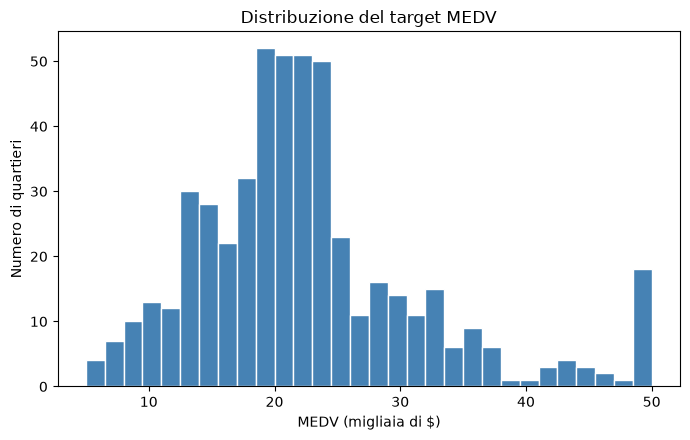

In [8]:
plt.figure()
plt.hist(df_clean["MEDV"], bins=30, color="steelblue", edgecolor="white")
plt.xlabel("MEDV (migliaia di $)")
plt.ylabel("Numero di quartieri")
plt.title("Distribuzione del target MEDV")
plt.tight_layout()
plt.show()

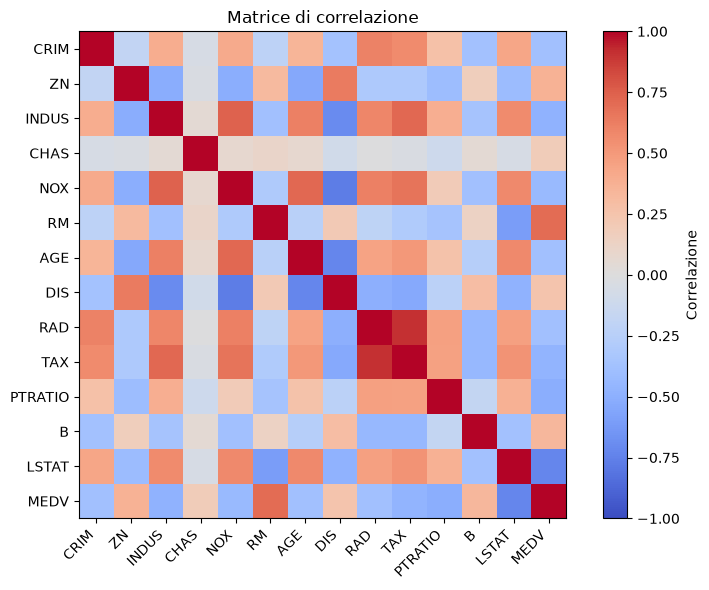

MEDV       1.000000
RM         0.695360
ZN         0.365943
B          0.333461
DIS        0.249929
CHAS       0.183844
CRIM      -0.379695
AGE       -0.380223
RAD       -0.381626
NOX       -0.427321
TAX       -0.468536
INDUS     -0.478657
PTRATIO   -0.507787
LSTAT     -0.721975
Name: MEDV, dtype: float64

In [9]:
corr = df_clean.corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlazione")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matrice di correlazione")
plt.tight_layout()
plt.show()

corr["MEDV"].sort_values(ascending=False)

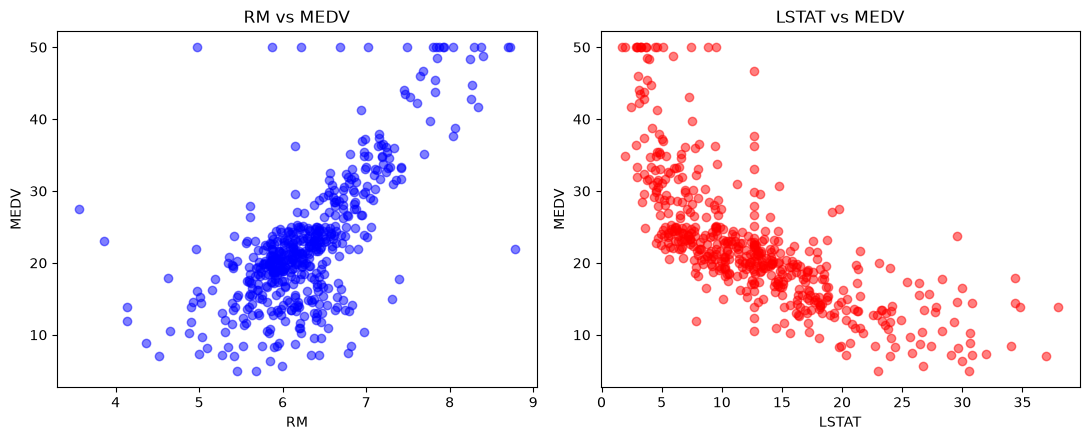

In [10]:
# RM e LSTAT sono le feature piu' correlate con MEDV
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(df_clean["RM"], df_clean["MEDV"], alpha=0.5, color="blue")
axes[0].set_xlabel("RM"); axes[0].set_ylabel("MEDV"); axes[0].set_title("RM vs MEDV")

axes[1].scatter(df_clean["LSTAT"], df_clean["MEDV"], alpha=0.5, color="red")
axes[1].set_xlabel("LSTAT"); axes[1].set_ylabel("MEDV"); axes[1].set_title("LSTAT vs MEDV")

plt.tight_layout()
plt.show()

## 4. Feature e target

In [11]:
X = df_clean.drop(columns=["MEDV"]).values
y = df_clean["MEDV"].values

print("X:", X.shape, "| y:", y.shape)

X: (506, 13) | y: (506,)


## 5. Split train/test (80/20)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 404 | Test: 102


## 6. Standardizzazione

Fit solo sul training set, transform sul test set (nessun data leakage).

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Linear Regression (baseline)

In [14]:
lin_reg = LinearRegression().fit(X_train_scaled, y_train)
y_pred_lr = lin_reg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

MAE : 3.16
RMSE: 5.00
R²  : 0.658


## 8. Ridge Regression

Regolarizzazione L2, alpha fisso a 1.0.

In [15]:
ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"MAE : {mae_ridge:.2f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R²  : {r2_ridge:.3f}")

MAE : 3.15
RMSE: 5.00
R²  : 0.658


## 9. Ridge con Cross-Validation

`GridSearchCV` sceglie alpha con 5-fold CV sul training set, senza toccare il test set.

In [16]:
griglia_alpha = {"alpha": [0.01, 0.1, 1, 10, 30, 100]}

ricerca_ridge = GridSearchCV(Ridge(), griglia_alpha, cv=5, scoring="r2", n_jobs=-1)
ricerca_ridge.fit(X_train_scaled, y_train)

print("Miglior alpha:", ricerca_ridge.best_params_["alpha"])
print("R2 medio in CV:", round(ricerca_ridge.best_score_, 3))

Miglior alpha: 10
R2 medio in CV: 0.714


In [17]:
y_pred_ridge_cv = ricerca_ridge.predict(X_test_scaled)

mae_ridge_cv = mean_absolute_error(y_test, y_pred_ridge_cv)
rmse_ridge_cv = np.sqrt(mean_squared_error(y_test, y_pred_ridge_cv))
r2_ridge_cv = r2_score(y_test, y_pred_ridge_cv)

print(f"MAE : {mae_ridge_cv:.2f}")
print(f"RMSE: {rmse_ridge_cv:.2f}")
print(f"R²  : {r2_ridge_cv:.3f}")

MAE : 3.15
RMSE: 5.01
R²  : 0.658


## 10. Confronto modelli

In [18]:
risultati = [
    ("Linear Regression", r2, rmse, mae),
    ("Ridge (alpha=1.0)", r2_ridge, rmse_ridge, mae_ridge),
    ("Ridge (CV, alpha ottimo)", r2_ridge_cv, rmse_ridge_cv, mae_ridge_cv),
]

tabella = pd.DataFrame(risultati, columns=["Modello", "R2", "RMSE", "MAE"]).round(3)
tabella

,Modello,R2,RMSE,MAE
0,Linear Regression,0.658,5.004,3.156
1,Ridge (alpha=1.0),0.658,5.005,3.155
2,"Ridge (CV, alpha ottimo)",0.658,5.009,3.146


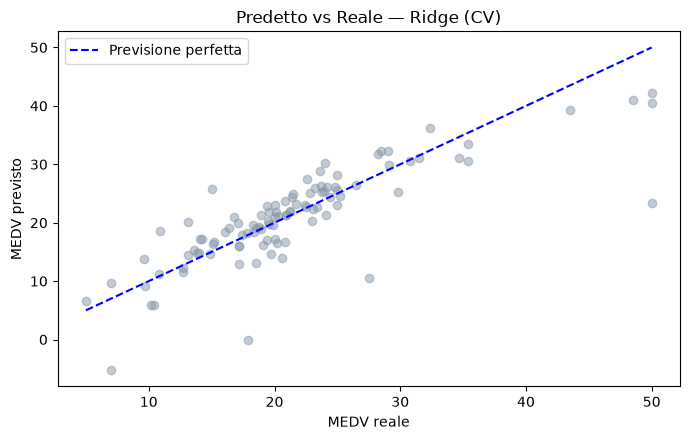

In [19]:
plt.figure()
plt.scatter(y_test, y_pred_ridge_cv, alpha=0.5, color="#8899aa")

lim = [y_test.min(), y_test.max()]
plt.plot(lim, lim, color="blue", linestyle="--", label="Previsione perfetta")

plt.xlabel("MEDV reale")
plt.ylabel("MEDV previsto")
plt.title("Predetto vs Reale — Ridge (CV)")
plt.legend()
plt.tight_layout()
plt.show()

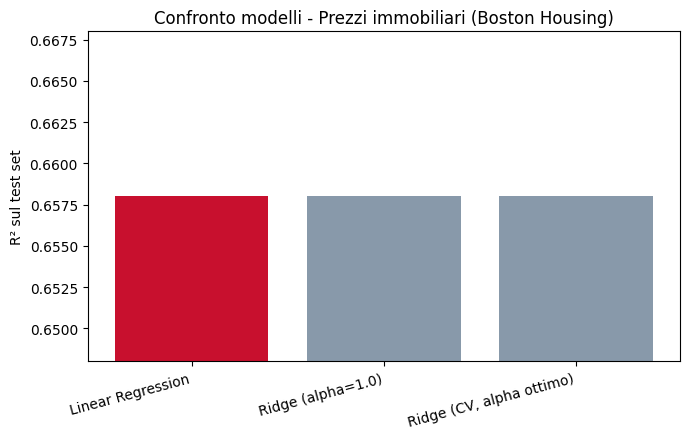

In [18]:
plt.figure()
nomi, valori_r2 = tabella["Modello"], tabella["R2"]

indice_migliore = valori_r2.idxmax()
colori = ["#C8102E" if i == indice_migliore else "#8899aa" for i in range(len(valori_r2))]

plt.bar(nomi, valori_r2, color=colori)
plt.ylabel("R² sul test set")
plt.title("Confronto modelli - Prezzi immobiliari (Boston Housing)")
plt.xticks(rotation=15, ha="right")

margine = (valori_r2.max() - valori_r2.min()) * 0.5 + 0.01
plt.ylim(valori_r2.min() - margine, valori_r2.max() + margine)
plt.tight_layout()
plt.show()

## Conclusioni

I tre modelli ottengono prestazioni quasi identiche sul test set (R² = 0.658, RMSE ≈ 5.00, MAE ≈ 3.15). La cross-validation individua alpha=10 come valore ottimale per Ridge, ma il guadagno non si riflette sul test set: con sole 13 feature e 404 osservazioni di training, l'OLS di base non soffre di overfitting significativo, quindi la regolarizzazione ha poco margine di miglioramento.

L'EDA conferma la scelta del modello lineare: RM e LSTAT — le feature più correlate con MEDV — mostrano relazioni visivamente lineari col target, e il grafico Predetto vs Reale segue bene la diagonale.

A parità di prestazioni, la scelta finale ricade sul modello più semplice e interpretabile: la **Regressione Lineare**. Ridge (con CV) resta l'alternativa da preferire in scenari con più feature o meno dati, dove il rischio di overfitting sarebbe maggiore.